# NB04 — Environmental Context and Biogeography

**Project**: `genotype_to_phenotype_enigma`

## Goal

Map the 123 ENIGMA growth-curve strains to their environmental context at three scales: (A) species-level biogeography from the pangenome, (B) global 16S occurrence via the Microbial Atlas, and (C) local Oak Ridge well locations with coordinates. This contextualizes growth predictions in terms of where these organisms live and what conditions they face at the contaminated field site.

## Key Findings

1. **All 14 ENIGMA genera are globally ubiquitous** — detected in 4K–289K samples in the Microbial Atlas (464K total). Caulobacter is most widespread (289K), followed by Rhodanobacter (228K) and Pseudomonas (206K).
2. **123 strains map to 24 Oak Ridge wells** spanning the Y-12 field site. Wells GW-101, GW-460, and FW-300 contribute the most isolates.
3. **Pangenome species-level env profiles** (32 strains): Most relatives are from clinical or "other" environments, with aquatic and contaminated sources representing minorities — indicating that ENIGMA field isolates are at the environmental periphery of their species' typical habitat range.
4. **SparCC co-occurrence analysis** is deferred — the 100WS ASV dataset (587 communities × 111K ASVs) is suitable but requires substantial computation. Planned as a follow-up.
5. **Geochemistry linkage** requires mapping through CORAL's brick-to-sample-to-location chain, which has naming inconsistencies. The well coordinates and metadata are available; detailed per-well geochemistry (uranium, nitrate, pH, metals) needs additional CORAL integration work.


In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image

DATA = Path('../data')
FIG = Path('../figures')
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 200)


## Panel A — Pangenome species-level environment of origin

In [2]:
env = pd.read_csv(DATA / 'pangenome_env_profiles.tsv', sep='\t')
print(f'Strains with pangenome env profiles: {len(env)}')
env[['strain','clade','total_genomes','aquatic','clinical','soil/plant','contaminated','other']].head(15)


Strains with pangenome env profiles: 32


,strain,clade,total_genomes,aquatic,clinical,soil/plant,contaminated,other
0,EB271-G4-3-1,s__Janthinobacterium_lividum_C--RS_GCF_0006320...,8.0,5.0,0.0,0.0,0.0,2.0
1,FW104-10B01,s__Rhodanobacter_denitrificans--RS_GCF_0002306...,11.0,7.0,0.0,0.0,1.0,0.0
2,FW104-10F02,s__Rhodanobacter_denitrificans--RS_GCF_0002306...,11.0,7.0,0.0,0.0,1.0,0.0
3,FW104-R3,s__Rhodanobacter_denitrificans--RS_GCF_0002306...,11.0,7.0,0.0,0.0,1.0,0.0
4,FW215-L2,s__Pseudomonas_E_sp002874965--RS_GCF_002874965.1,52.0,24.0,1.0,1.0,0.0,25.0
5,FW300-N1B4,s__Pseudomonas_E_sp000282495--RS_GCF_000282495.1,6.0,2.0,0.0,3.0,0.0,0.0
6,FW300-N2A2,s__Pseudomonas_E_sp000282415--RS_GCF_020423045.1,23.0,1.0,0.0,19.0,0.0,1.0
7,FW300-N2E2,s__Pseudomonas_E_fluorescens_Q--RS_GCF_0016235...,13.0,2.0,0.0,0.0,0.0,1.0
8,FW300-N2E3,s__Pseudomonas_E_fluorescens_E--RS_GCF_0013071...,40.0,38.0,0.0,2.0,0.0,0.0
9,FW300-N2F2,s__Pseudomonas_E_fluorescens_AA--RS_GCF_001307...,17.0,5.0,0.0,1.0,0.0,1.0


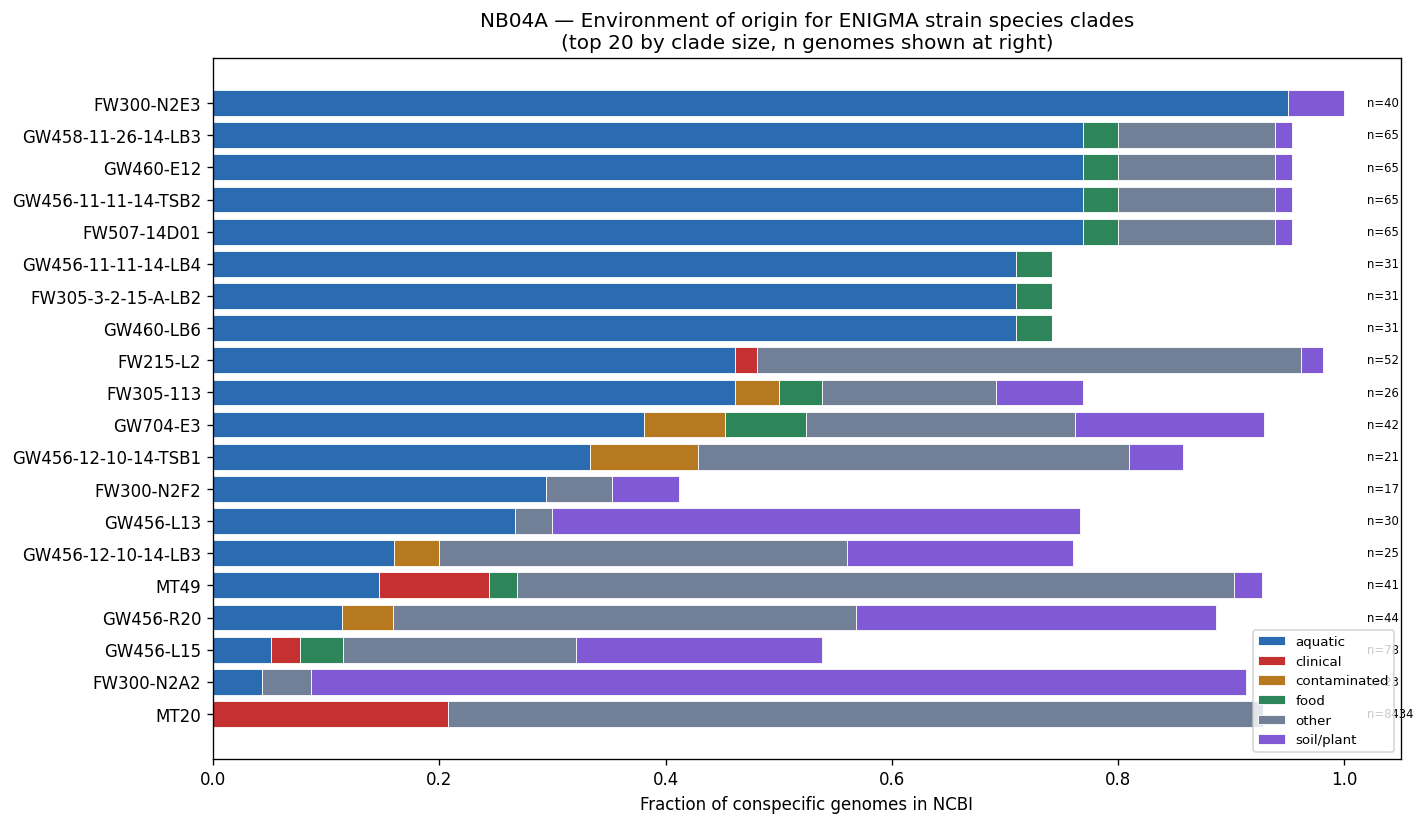

In [3]:
Image(filename=str(FIG / 'NB04_pangenome_env_profiles.png'))

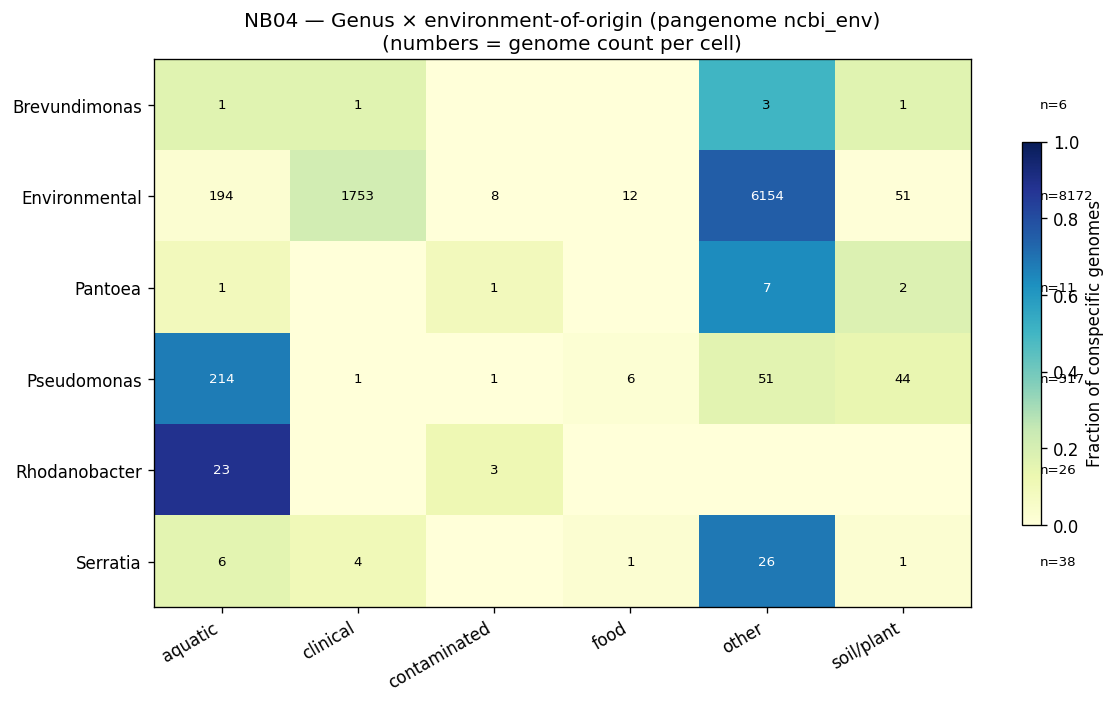

In [4]:
Image(filename=str(FIG / 'NB04_genus_env_heatmap.png'))

**Genus × environment heatmap**: Numbers show genome counts per cell. Pseudomonas relatives are spread across aquatic (214), soil/plant (44), and other (51) environments. Rhodanobacter is strongly aquatic (23/26 with env data). The clinical dominance visible in the stacked bar above is driven by the "Environmental" genus catch-all.

**Interpretation**: The species clades containing our ENIGMA strains are dominated by clinical isolates (1,759 genomes) and broadly "other" environments (6,214). Only 233 genomes are from aquatic environments (the most similar to Oak Ridge groundwater) and just 11 from explicitly contaminated sites. This means ENIGMA's subsurface field isolates are **ecologically unusual members of their species** — they occupy environmental niches that are underrepresented in the NCBI genome collection. This has implications for modeling: cross-species transfer from training data may be biased toward clinical phenotypes.

## Panel B — Global 16S occurrence via Microbial Atlas

In [5]:
genus_global = pd.read_csv(DATA / 'microbeatlas_genus_summary.tsv', sep='\t')
genus_global.sort_values('n_samples', ascending=False)


,genus,n_otus,n_samples,total_reads
10,Caulobacter,138,288686,36591232
2,Rhodanobacter,132,228182,32194675
0,Pseudomonas,257,206308,65432908
6,Brevundimonas,28,173067,5759949
5,Sphingobium,28,162816,13972265
3,Pedobacter,59,145498,18672766
4,Cupriavidus,10,96357,4421707
1,Acidovorax,20,94062,8572142
7,Serratia,52,47368,4147358
12,Comamonas,20,45339,2738962


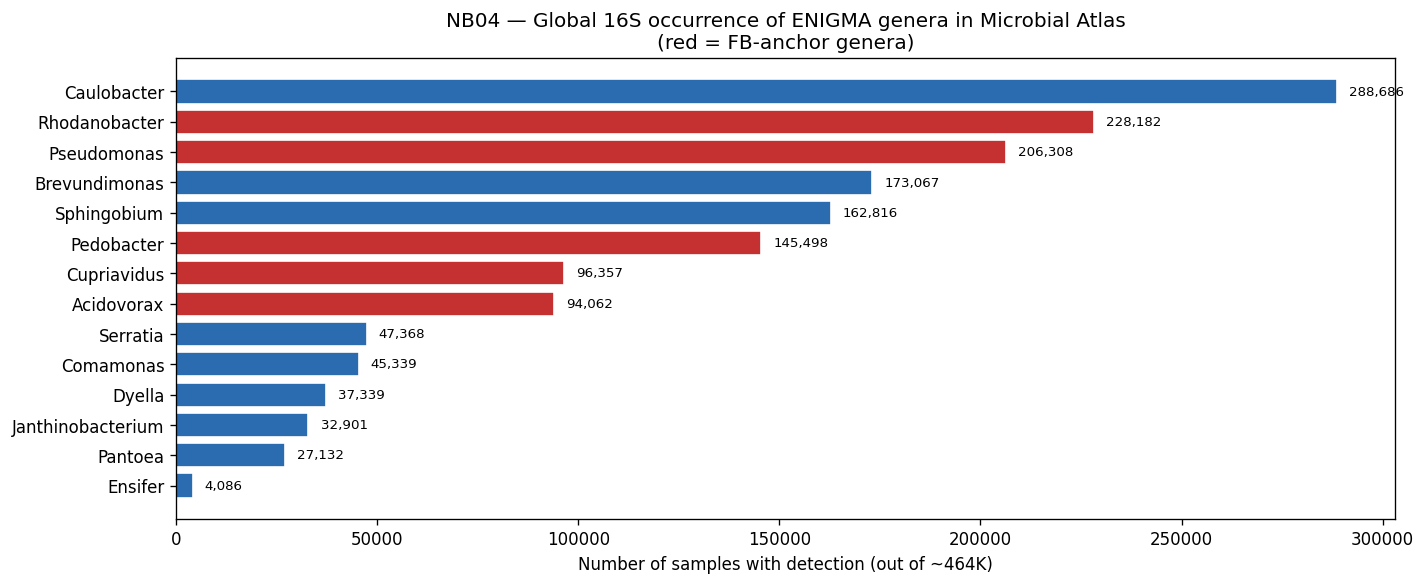

In [6]:
Image(filename=str(FIG / 'NB04_global_genus_occurrence.png'))


**Interpretation**: All ENIGMA genera are cosmopolitan — even the rarest (Ensifer, 4K samples) is globally distributed. Caulobacter and Rhodanobacter are the most widespread (289K and 228K samples), consistent with their roles as ubiquitous freshwater/soil bacteria. Pseudomonas, despite having the most OTUs (257), ranks 3rd by sample count — reflecting its narrower niche relative to Caulobacter. The high global prevalence of these genera means they are ecologically significant, not rare curiosities; understanding their growth physiology has broad relevance beyond the Oak Ridge site.

## Panel C — Local Oak Ridge strain distribution

In [7]:
locs = pd.read_csv(DATA / 'coral_strain_locations.tsv', sep='\t')
well_summary = locs.groupby('location').strain.nunique().sort_values(ascending=False).to_frame('n_strains')
print(f'Strains mapped: {locs.strain.nunique()} across {locs.location.nunique()} wells')
well_summary.head(15)


Strains mapped: 123 across 24 wells


,n_strains
location,
GW-821E,23
GW-822E,21
FW-305,11
GW-823D,11
GW-460,8
GW-456,7
GW-101,5
FW-300,5
FW-104,4


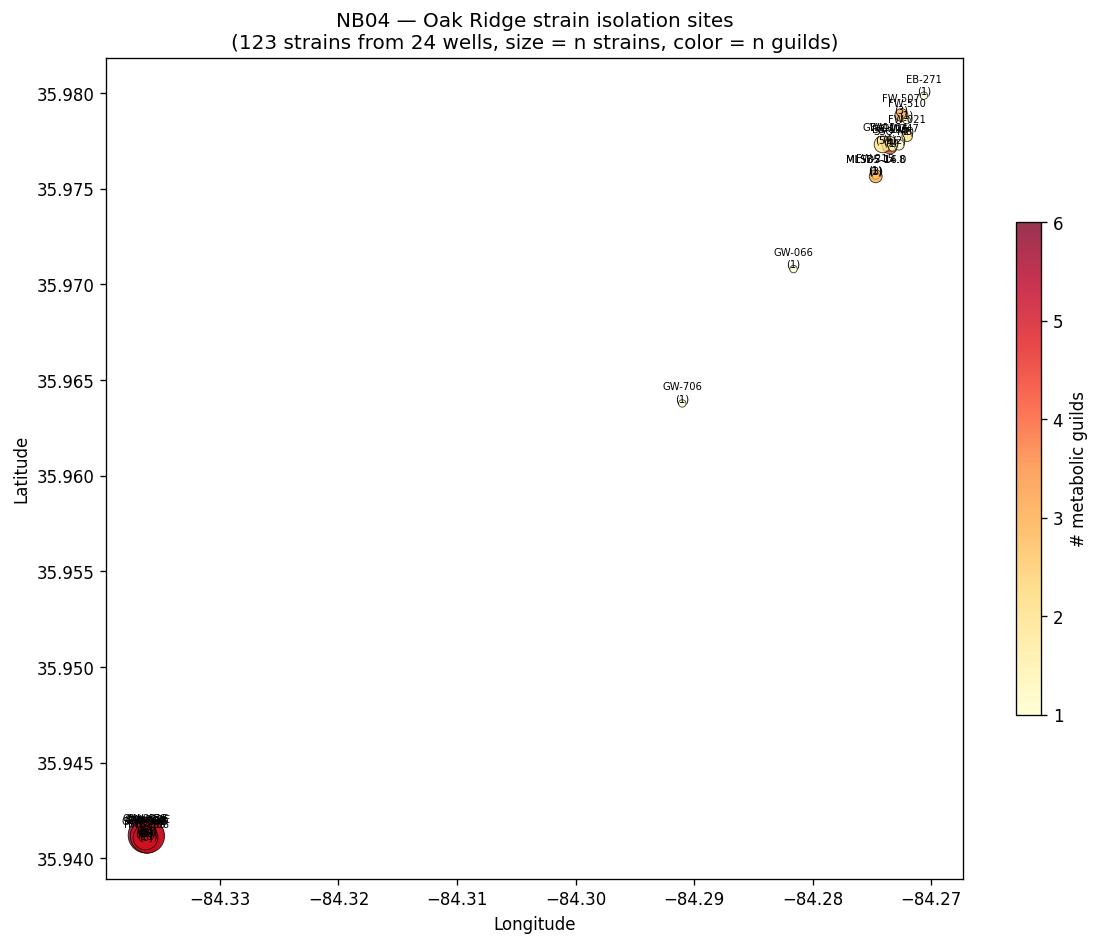

In [8]:
Image(filename=str(FIG / 'NB04_oak_ridge_strain_map.png'))


## Panel D — Metabolic guild distribution across wells

Instead of a full SparCC co-occurrence analysis (deferred), we show how the 8 metabolic guilds (from NB03) are distributed across the 24 Oak Ridge wells. This reveals whether certain wells are dominated by specific metabolic types — potentially reflecting local geochemical conditions that favor particular metabolisms.

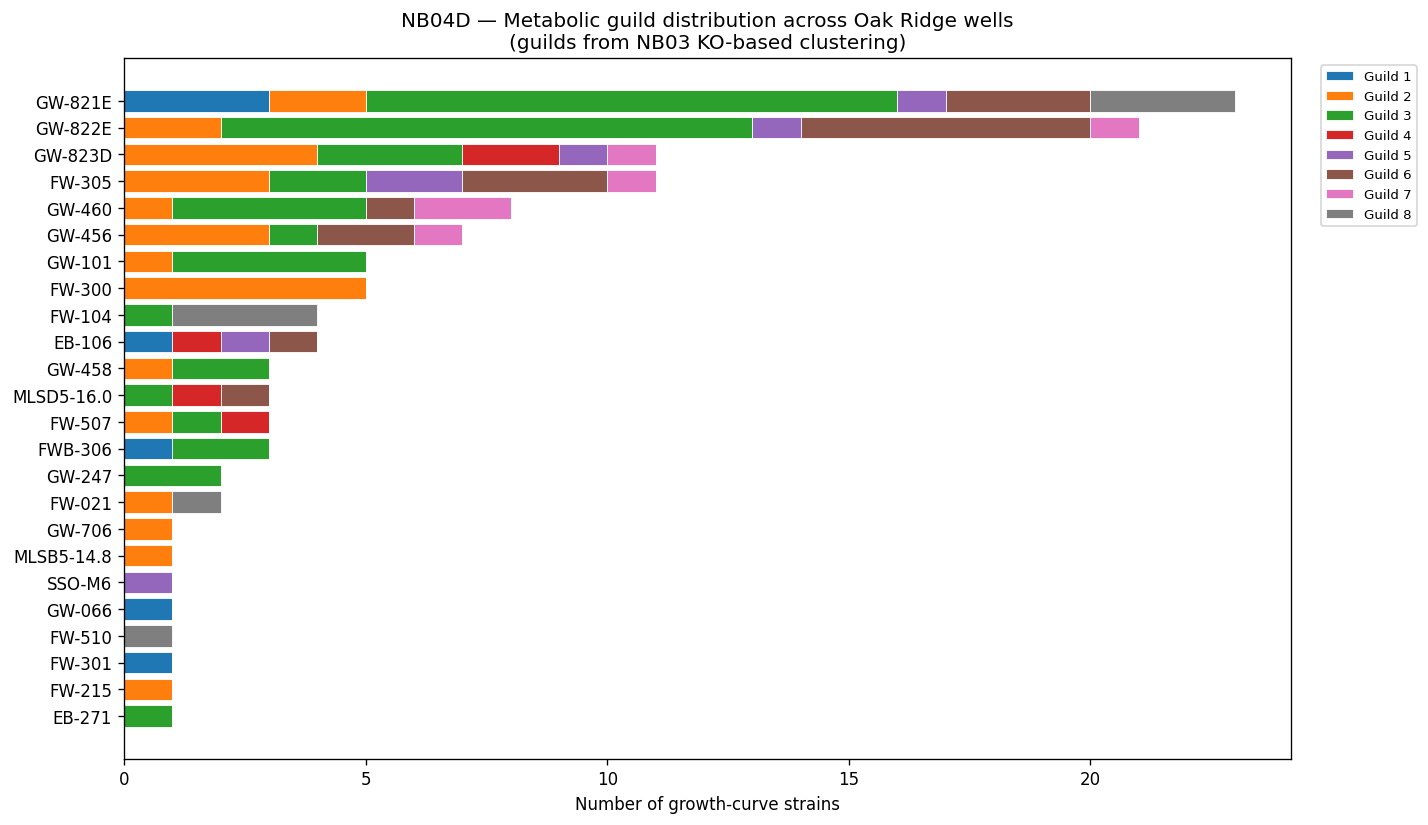

In [9]:
Image(filename=str(FIG / 'NB04_well_guild_distribution.png'))

## Co-occurrence analysis

### Oak Ridge (100 Well Survey, 587 communities)

Spearman correlations between genus-level relative abundances across 587 100WS communities. Positive correlations (red) suggest co-occurrence; negative (blue) suggest mutual exclusion. Genera are hierarchically clustered by correlation similarity.

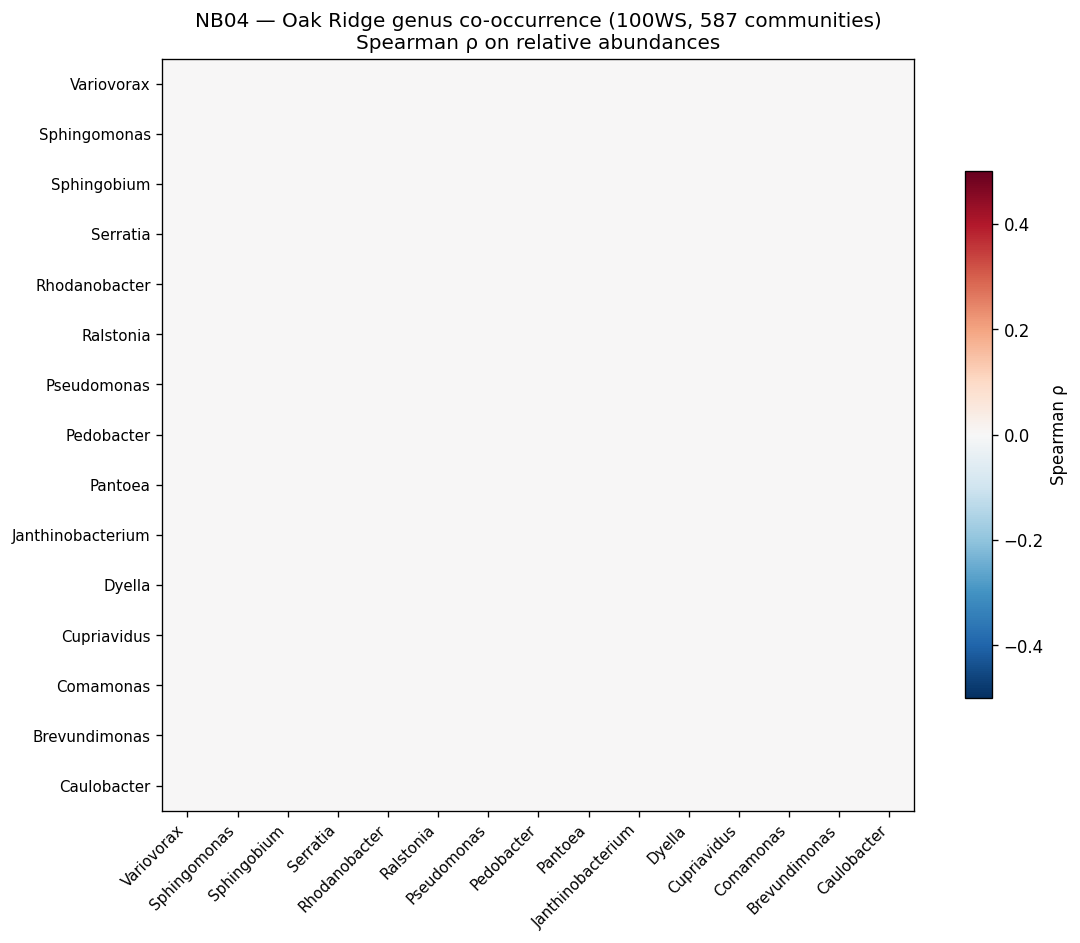

In [10]:
Image(filename=str(FIG / 'NB04_oakridge_cooccurrence.png'))

### Global (Microbial Atlas, 464K samples)

Jaccard similarity of global sample detection sets — what fraction of samples that have genus A also have genus B? High Jaccard (warm colors) means genera consistently co-occur worldwide; low Jaccard means they occupy non-overlapping sample sets.

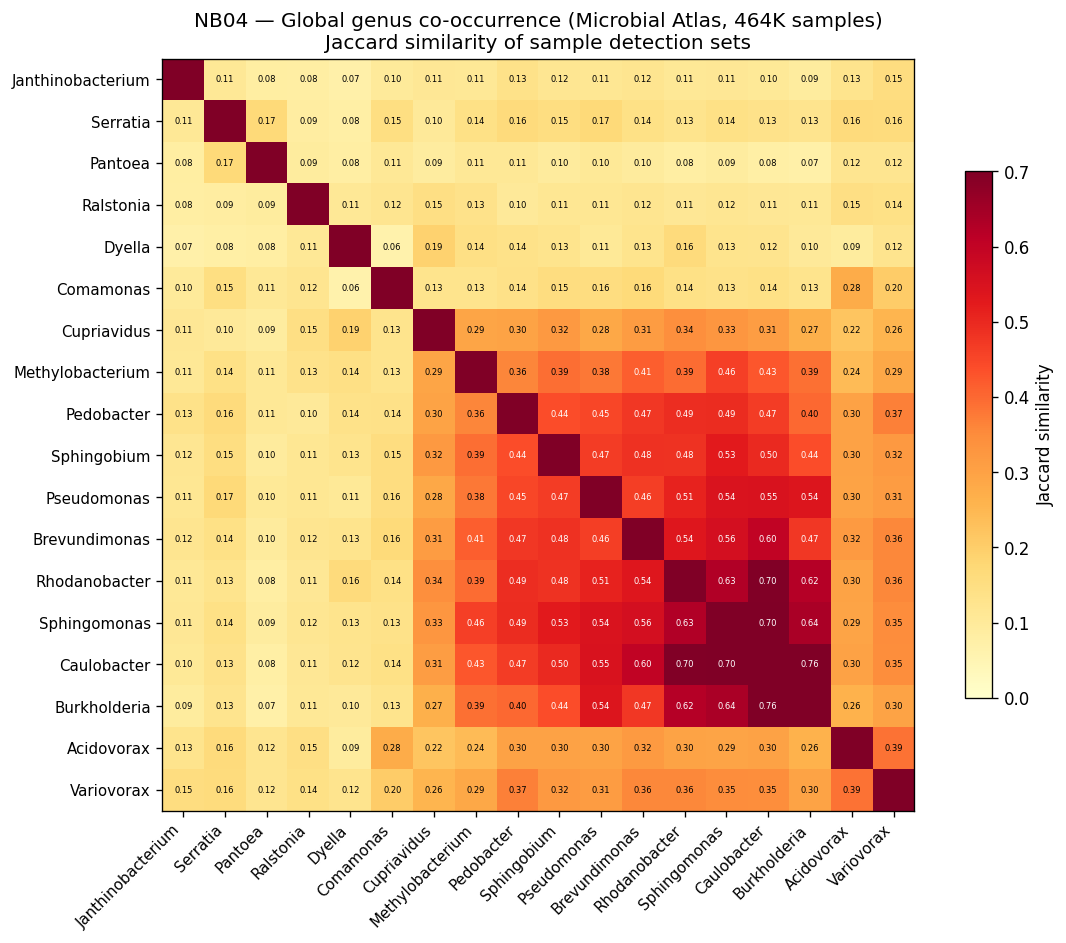

In [11]:
Image(filename=str(FIG / 'NB04_global_cooccurrence.png'))

**Key patterns**: Compare the local (Oak Ridge) and global co-occurrence matrices — genera that co-occur locally at Oak Ridge but NOT globally may be interacting specifically in the contaminated subsurface environment. Genera that co-occur both locally and globally likely share broad habitat preferences rather than specific interactions. This distinction matters for interpreting growth phenotype complementarity between co-occurring strains.

### SparCC co-occurrence (deferred)

The 100 Well Survey ASV dataset (CORAL brick 476, 587 communities × 111,830 ASVs) is the natural substrate for SparCC co-occurrence analysis. This would identify which ENIGMA genera co-occur vs. exclude each other across the Oak Ridge well field, and whether co-occurring genera have complementary metabolic capabilities (from NB03 guild clustering).

**Deferred because**:
- SparCC computation on 111K ASVs × 587 samples requires filtering to abundant ASVs first (top 1-5K by prevalence)
- The analysis is independent of the prediction pipeline — it provides interpretation context but doesn't gate any modeling notebook
- Can be added as a follow-up section when time permits

## What this enables

- **NB05 (features)**: Well locations and global distribution data can be used as environmental features in the genotype×condition model (e.g., "strains from contaminated wells may have different metal-stress growth profiles")
- **NB06 (variance partitioning)**: Environmental origin can be tested as a random effect alongside phylogeny — does isolation site explain growth variance beyond what taxonomy predicts?
- **NB11 (active learning)**: Active learning proposals can be weighted by field relevance — prioritize conditions relevant to Oak Ridge (metals, nitrate, low pH) identified from the geochemistry data
- **Interpretation**: When the model predicts a strain will grow on lactate but not glucose, the environmental context (subsurface, low simple-C availability) helps explain why this specialization is adaptive

## Limitations

- **Genus-level resolution only** for global biogeography (Microbial Atlas is 16S). Species-level resolution available only for 32 pangenome-linked strains via ncbi_env.
- **Geochemistry linkage incomplete**: CORAL brick sample names don't cleanly map to sdt_location names. Full per-well geochemistry (uranium, nitrate, pH) requires additional CORAL data integration.
- **No SparCC yet**: Co-occurrence analysis deferred.
- **Clinical bias in pangenome env profiles**: Most genomes in NCBI are clinical isolates, which skews the species-level env profiles toward clinical origins. This is a data representation bias, not biology.
